<a href="https://colab.research.google.com/github/IvanderAs/ExplainableAI/blob/main/XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Define the dataset path
data_path = '/content/PS_20174392719_1491204439457_log.csv' # Changed to the new dataset

try:
    df = pd.read_csv(data_path)
    print(f"Successfully loaded data from {data_path}.")
except FileNotFoundError:
    print(f"Error: The file '{data_path}' was not found. Please upload the dataset to your Colab environment or specify the correct path.")
    print("You can usually find this dataset (Synthetic Financial Dataset) on Kaggle.")
    df = None # Set df to None to indicate failure

if df is not None:
    print("\nDataset Head:")
    display(df.head())
    print("\nDataset Info:")
    df.info()
    print("\nDataset Description:")
    display(df.describe())

Successfully loaded data from /content/PS_20174392719_1491204439457_log.csv.

Dataset Head:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4438002 entries, 0 to 4438001
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 372.5+ MB

Dataset Description:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,4.438002e+06,4.438002e+06,4.438001e+06,4.438001e+06,4.438001e+06,4.438001e+06,4.438001e+06,4.438001e+06
mean,1.731931e+02,1.743085e+05,8.402781e+05,8.618332e+05,1.035527e+06,1.160887e+06,8.190625e-04,6.759800e-07
std,9.566144e+01,6.223288e+05,2.913043e+06,2.949618e+06,2.837044e+06,3.210356e+06,2.860755e-02,8.221799e-04
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.300000e+02,1.278451e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.860000e+02,7.489946e+04,1.424400e+04,0.000000e+00,1.352295e+05,2.176928e+05,0.000000e+00,0.000000e+00
75%,2.530000e+02,2.081011e+05,1.083080e+05,1.465019e+05,9.404200e+05,1.112687e+06,0.000000e+00,0.000000e+00
max,3.230000e+02,9.244552e+07,4.381886e+07,4.368662e+07,3.249151e+08,3.555534e+08,1.000000e+00,1.000000e+00


## 2. Data Preprocessing

We need to prepare the data for machine learning. This typically involves:
- Handling categorical features (e.g., 'type', 'nameOrig', 'nameDest').
- Dropping irrelevant columns.
- Scaling numerical features.
- Checking for missing values (though this dataset is often clean).

For `nameOrig` and `nameDest`, these columns have a very high cardinality (many unique values), making direct one-hot encoding infeasible. They represent individual accounts. For fraud detection, the transaction type (`type`) and transaction amounts are usually more indicative. We'll drop `nameOrig` and `nameDest` for simplicity in this initial pass, focusing on transaction type and numerical features.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

if 'df' in globals() and df is not None:
    # Agar ringan, kita ambil subset data
    fraud_df = df[df['isFraud'] == 1]
    non_fraud_df = df[df['isFraud'] == 0].sample(n=min(1000000, len(df[df['isFraud'] == 0])), random_state=42)
    df_sampled = pd.concat([fraud_df, non_fraud_df])

    # Drop columns
    df_processed = df_sampled.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])

    # Handle categorical features ('type')
    df_processed = pd.get_dummies(df_processed, columns=['type'], drop_first=True, dtype=int)

    # Separate features (X) and target (y)
    X = df_processed.drop(columns=['isFraud'])
    y = df_processed['isFraud']

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Scale numerical features
    scaler = StandardScaler()
    numerical_cols = X_train.select_dtypes(include=np.number).columns
    X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

    print("\nPreprocessing Selesai.")
    display(X_train.head())
else:
    print("Error: Variabel 'df' tidak ditemukan. Mohon jalankan sel pemuatan data (cell 1733384f) terlebih dahulu.")


Preprocessing Selesai.


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
3852509,1.147801,0.097412,-0.289249,-0.291971,1.080030,0.987687,1.349364,-0.078978,-0.712782,-0.302142
279768,-1.654904,0.410904,-0.289115,-0.291971,0.163720,0.240726,-0.741090,-0.078978,-0.712782,3.309702
900424,-1.372542,-0.218581,-0.289249,-0.291971,-0.364074,-0.360478,-0.741090,-0.078978,1.402953,-0.302142
2326770,0.154305,0.131630,-0.289249,-0.291971,0.985554,0.911044,1.349364,-0.078978,-0.712782,-0.302142
2573235,0.353004,-0.173483,-0.266626,-0.291971,-0.157769,-0.157761,1.349364,-0.078978,-0.712782,-0.302142


## 3. Model Training

We will train a Logistic Regression model, which is a common and interpretable choice for binary classification tasks like fraud detection. Given the large dataset size, Logistic Regression offers a good balance of performance and computational efficiency.

### 3.1. Mengatasi Ketidakseimbangan Kelas dengan SMOTE

Dataset fraud biasanya sangat tidak seimbang, dengan jumlah transaksi fraud yang jauh lebih sedikit dibandingkan transaksi non-fraud. Ini dapat menyebabkan model cenderung memprediksi kelas mayoritas (non-fraud) dan mengabaikan kelas minoritas (fraud).

**SMOTE (Synthetic Minority Over-sampling Technique)** adalah teknik over-sampling yang menghasilkan sampel sintetis dari kelas minoritas. Ini membantu menyeimbangkan distribusi kelas, yang dapat meningkatkan kinerja model dalam mendeteksi kelas minoritas.

In [ ]:
from imblearn.over_sampling import SMOTE
import gc

if 'X_train' in globals() and 'y_train' in globals():
    print("Applying SMOTE to training data (Optimized)... ")

    # Jika data terlalu besar, kita bisa membatasi jumlah sampel mayoritas sebelum SMOTE
    # Namun untuk saat ini kita coba jalankan dengan random_state tetap.
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Hapus variabel yang tidak lagi dibutuhkan untuk menghemat RAM
    # del X_train, y_train # Aktifkan ini jika RAM masih penuh
    gc.collect()

    print(f"Shape after SMOTE: {X_train_resampled.shape}")
    print("Distribution of y_train_resampled:\n", y_train_resampled.value_counts())
else:
    print("X_train atau y_train tidak ditemukan.")

Applying SMOTE to training data (Optimized)... 
Shape after SMOTE: (1400000, 10)
Distribution of y_train_resampled:
 isFraud
0.0    700000
1.0    700000
Name: count, dtype: int64


### Visualisasi SMOTE (Synthesized Data Generation)

SMOTE bekerja dengan cara mengambil sampel minoritas dan mencari k-tetangga terdekatnya (KNN), lalu membuat titik baru di sepanjang garis yang menghubungkan titik-titik tersebut. Plot di bawah menunjukkan bagaimana kelas minoritas (Fraud) diperbanyak sehingga seimbang dengan kelas mayoritas.

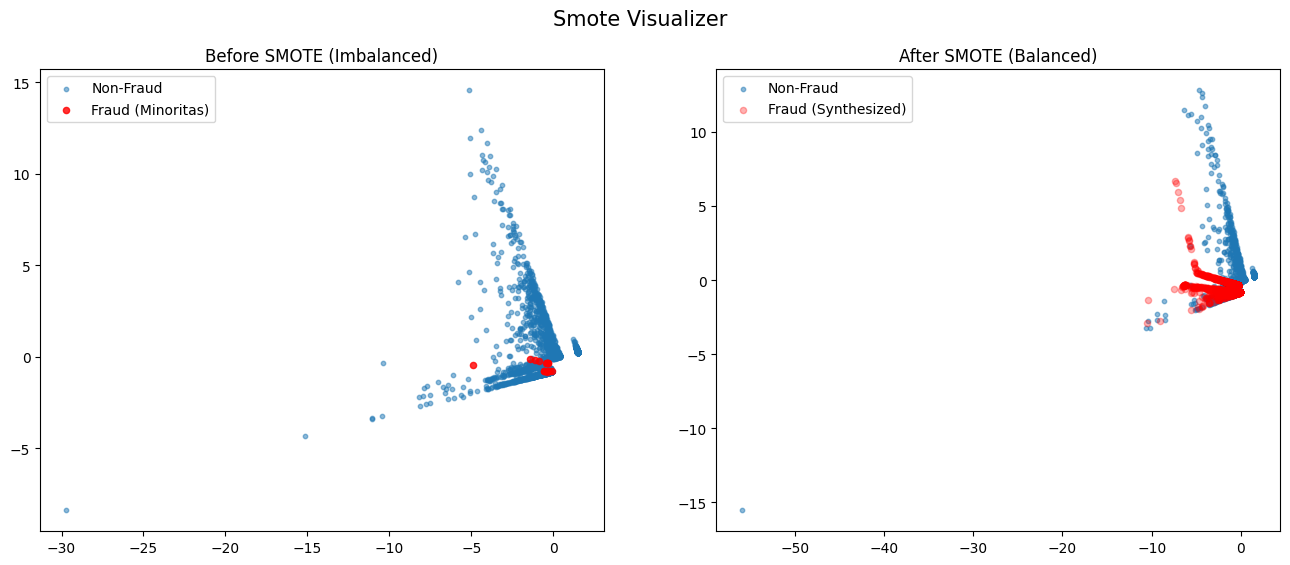

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

if 'X_train' in locals() and 'X_train_resampled' in locals():
    # Gunakan PCA untuk mereduksi dimensi ke 2D agar bisa diplot
    pca = PCA(n_components=2)

    # Ambil sampel kecil agar plot tidak terlalu padat dan proses cepat
    sample_size = 5000
    X_before = X_train.sample(n=min(sample_size, len(X_train)), random_state=42)
    y_before = y_train.loc[X_before.index]

    X_after = X_train_resampled.sample(n=min(sample_size, len(X_train_resampled)), random_state=42)
    y_after = y_train_resampled.loc[X_after.index]

    # Fit PCA pada data asli dan transform keduanya
    pca.fit(X_before)
    X_pca_before = pca.transform(X_before)
    X_pca_after = pca.transform(X_after)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot Before SMOTE
    ax1.scatter(X_pca_before[y_before == 0, 0], X_pca_before[y_before == 0, 1], label='Non-Fraud', alpha=0.5, s=10)
    ax1.scatter(X_pca_before[y_before == 1, 0], X_pca_before[y_before == 1, 1], label='Fraud (Minoritas)', alpha=0.8, s=20, c='red')
    ax1.set_title('Before SMOTE (Imbalanced)')
    ax1.legend()

    # Plot Sesudah SMOTE
    ax2.scatter(X_pca_after[y_after == 0, 0], X_pca_after[y_after == 0, 1], label='Non-Fraud', alpha=0.5, s=10)
    ax2.scatter(X_pca_after[y_after == 1, 0], X_pca_after[y_after == 1, 1], label='Fraud (Synthesized)', alpha=0.3, s=20, c='red')
    ax2.set_title('After SMOTE (Balanced)')
    ax2.legend()

    plt.suptitle('Smote Visualizer', fontsize=15)
    plt.show()
else:
    print("Jalankan sel SMOTE terlebih dahulu untuk melihat visualisasi ini.")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import gc

if 'X_train_resampled' in globals():
    print("Training Logistic Regression (Memory Optimized)... ")
    # Menggunakan solver 'liblinear' dengan limit iterasi agar tidak looping selamanya
    model = LogisticRegression(solver='liblinear', max_iter=100, random_state=42)
    model.fit(X_train_resampled, y_train_resampled)

    # Prediksi secara bertahap atau langsung jika RAM cukup
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    gc.collect()

    print("Model Training Complete.")
    print("\nClassification Report (Threshold 0.5):")
    print(classification_report(y_test, y_pred))
else:
    print("Data resampled tidak ditemukan.")

Training Logistic Regression (Memory Optimized)... 
Model Training Complete.

Classification Report (Threshold 0.5):
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97    300000
         1.0       0.07      0.97      0.12      1091

    accuracy                           0.95    301091
   macro avg       0.53      0.96      0.55    301091
weighted avg       1.00      0.95      0.97    301091



## 6. Penjelasan Model (XAI) dengan SHAP dan LIME

Bagian ini dipindahkan ke akhir sesuai permintaan untuk memberikan gambaran mendalam tentang faktor apa saja yang mempengaruhi keputusan model setelah evaluasi performa selesai.

In [ ]:
# Install SHAP and LIME
%pip install shap lime

print("SHAP and LIME libraries installed.")

SHAP and LIME libraries installed.


In [ ]:
!pip install imblearn
print("imblearn library installed.")

imblearn library installed.


### 4.1. SHAP Explanations

SHAP values tell us how much each feature contributes to a prediction, both positively and negatively. We'll look at both global (overall model behavior) and local (individual prediction) explanations.

#### 4.1.1. Global SHAP Explanations

### 4.3 Perbedaan Persebaran Data Fraud dan Non-Fraud

Untuk memahami perbedaan antara transaksi penipuan dan non-penipuan, mari kita visualisasikan distribusi fitur utama berdasarkan label `isFraud`.

Number of non-fraudulent transactions: 700000
Number of fraudulent transactions: 2544
Fraud percentage: 0.3621%

Visualizing distribution of Numerical Features:


/tmp/ipykernel_706/2762865261.py:29: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


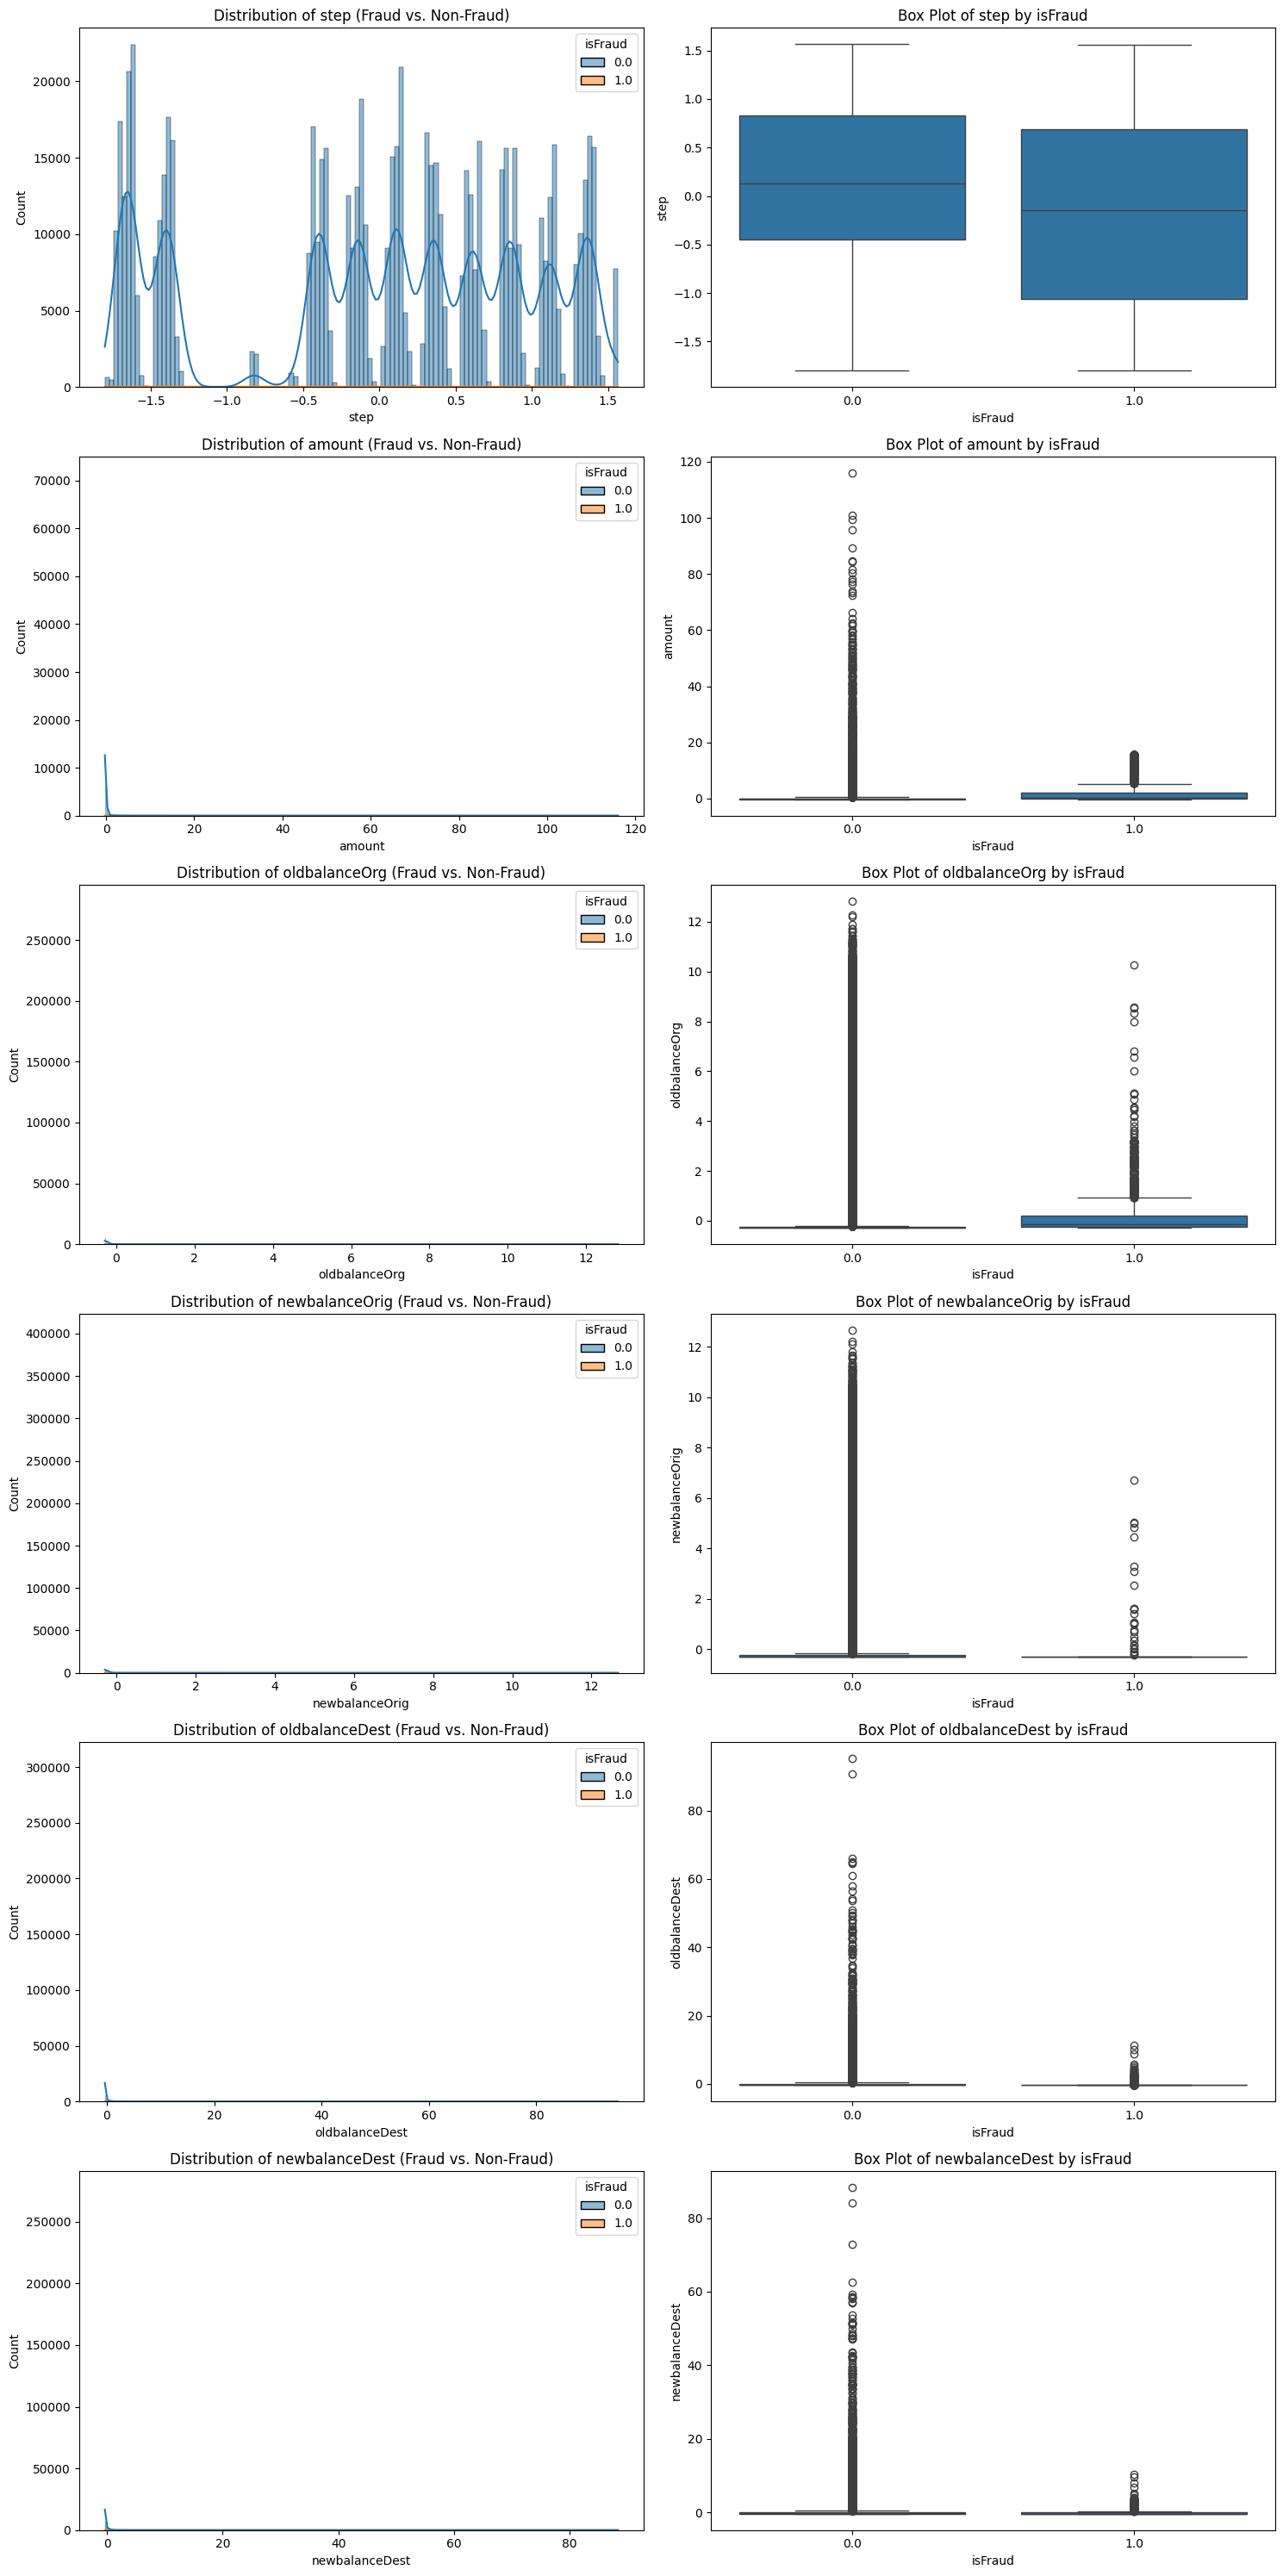

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine X_train and y_train for plotting
train_data_for_plot = X_train.copy()
train_data_for_plot['isFraud'] = y_train

fraud_counts = train_data_for_plot['isFraud'].value_counts()
print(f"Number of non-fraudulent transactions: {fraud_counts.get(0, 0)}")
print(f"Number of fraudulent transactions: {fraud_counts.get(1, 0)}")
print(f"Fraud percentage: {fraud_counts.get(1, 0) / len(train_data_for_plot) * 100:.4f}%")

# Separate numerical and categorical (one-hot encoded 'type') features
numerical_features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
categorical_features = [col for col in X_train.columns if 'type_' in col]

print("\nVisualizing distribution of Numerical Features:")
# Plot distributions for numerical features
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(15, 5 * len(numerical_features)))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(data=train_data_for_plot, x=feature, hue='isFraud', kde=True, ax=axes[2*i])
    axes[2*i].set_title(f'Distribution of {feature} (Fraud vs. Non-Fraud)')

    sns.boxplot(data=train_data_for_plot, x='isFraud', y=feature, ax=axes[2*i+1])
    axes[2*i+1].set_title(f'Box Plot of {feature} by isFraud')

plt.tight_layout()
plt.show()


Visualizing distribution of Categorical (Type) Features:


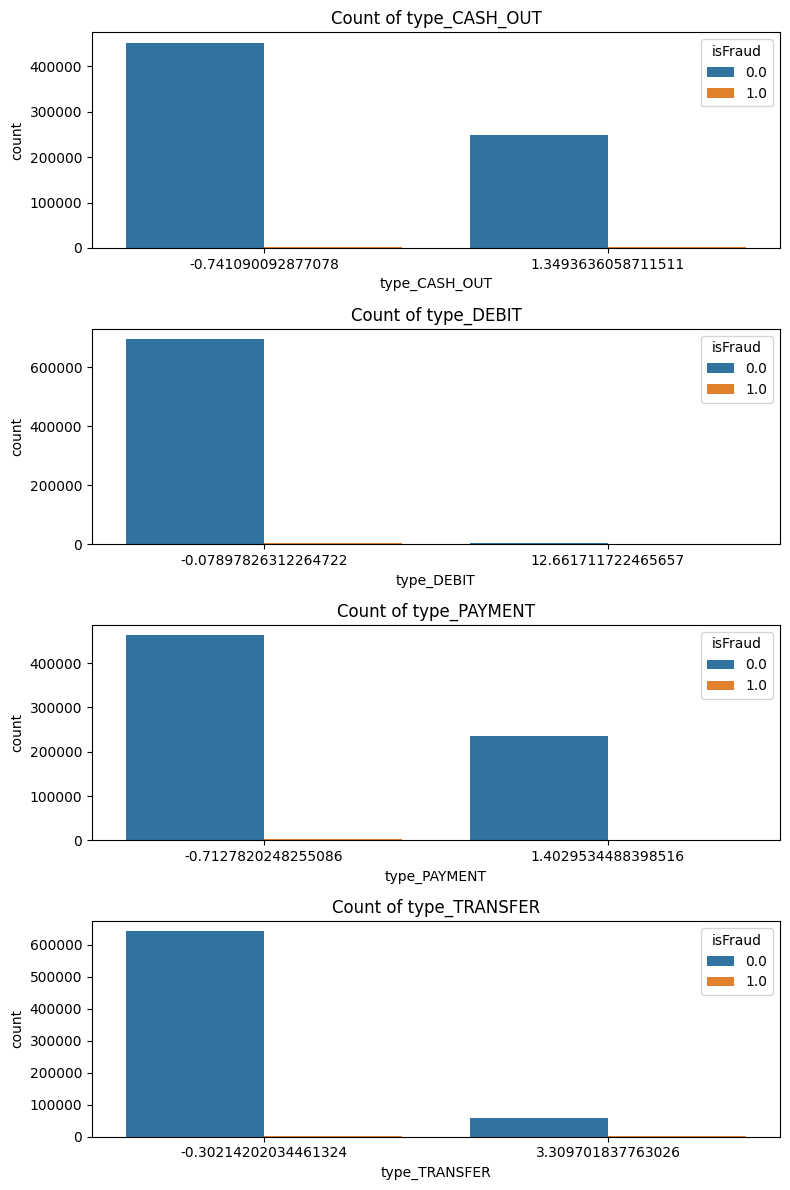

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nVisualizing distribution of Categorical (Type) Features:")
# Pastikan train_data_for_plot tersedia
train_data_for_plot = X_train.copy()
train_data_for_plot['isFraud'] = y_train

categorical_features = [col for col in X_train.columns if 'type_' in col]

fig_cat, axes_cat = plt.subplots(len(categorical_features), 1, figsize=(8, 3 * len(categorical_features)))
if len(categorical_features) == 1: axes_cat = [axes_cat]

for i, feature in enumerate(categorical_features):
    sns.countplot(data=train_data_for_plot, x=feature, hue='isFraud', ax=axes_cat[i])
    axes_cat[i].set_title(f'Count of {feature}')

plt.tight_layout()
plt.show()

Generating SHAP summary plot (bar chart)...


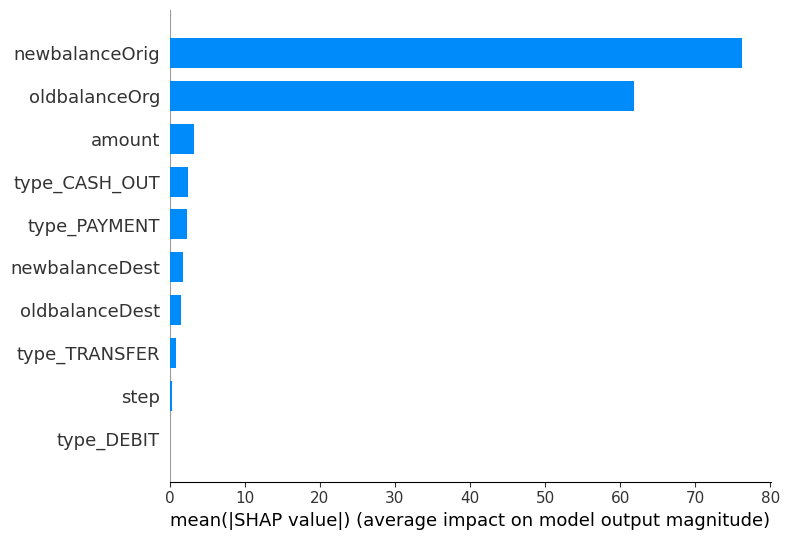

In [ ]:
import shap
import matplotlib.pyplot as plt

if df is not None and 'model' in locals(): # Check if model was successfully trained
    # Use a subset of the data for SHAP, as it can be computationally intensive
    # For linear models, KernelExplainer is appropriate
    explainer = shap.LinearExplainer(model, X_train)
    shap_values = explainer.shap_values(X_test.sample(n=1000, random_state=42))

    print("Generating SHAP summary plot (bar chart)...")
    shap.summary_plot(shap_values, X_test.sample(n=1000, random_state=42), plot_type="bar")
    plt.show()
else:
    print("Skipping SHAP global explanation as model was not trained or df is None.")

#### 4.1.2. Local SHAP Explanations (for an individual transaction)

Let's pick an example transaction (e.g., an actual fraudulent one if available, or a random one) and see its individual SHAP explanation.

In [ ]:
if df is not None and 'model' in locals():
    # Find an example transaction. Let's try to find a fraudulent one if possible.
    fraud_indices = y_test[y_test == 1].index
    if not fraud_indices.empty:
        idx_to_explain = fraud_indices[0] # Explain the first fraudulent transaction in the test set
        print(f"Explaining a fraudulent transaction (index {idx_to_explain} in the original test set).")
    else:
        idx_to_explain = X_test.index[0] # Default to the first transaction if no fraud found
        print(f"No fraudulent transactions found in test set, explaining a regular transaction (index {idx_to_explain}).")

    # Get the feature values for this specific instance
    instance_to_explain = X_test.loc[[idx_to_explain]]

    # Calculate SHAP values for this instance
    explainer = shap.LinearExplainer(model, X_train)
    shap_values_instance = explainer.shap_values(instance_to_explain)

    print("Generating SHAP force plot for the selected instance...")
    shap.initjs() # Initialize Javascript for interactive plots
    shap.force_plot(explainer.expected_value, shap_values_instance, instance_to_explain)

else:
    print("Skipping SHAP local explanation as model was not trained or df is None.")

Explaining a fraudulent transaction (index 1641997 in the original test set).
Generating SHAP force plot for the selected instance...


### 4.2. LIME Explanations

LIME provides an interpretable model that is locally faithful to the classifier. It explains individual predictions by perturbing the input and observing the changes in the model's output.

In [ ]:
import lime
import lime.lime_tabular

if df is not None and 'model' in locals():
    # Create a LIME explainer. For tabular data, use LimeTabularExplainer.
    # 'feature_names' are crucial for good explanations
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train.values, # LIME expects numpy arrays
        feature_names=X_train.columns.tolist(),
        class_names=['not fraud', 'fraud'], # The target class names
        mode='classification'
    )

    # Use the same instance as for SHAP local explanation
    if 'instance_to_explain' in locals():
        print("Generating LIME explanation for the selected instance...")
        # LIME expects a prediction function that outputs probabilities for each class
        # Ensure the model's predict_proba outputs probabilities in the correct order (class 0, class 1)
        exp = explainer_lime.explain_instance(
            data_row=instance_to_explain.values[0], # LIME expects a single data row (numpy array)
            predict_fn=model.predict_proba,
            num_features=5 # Show top 5 contributing features
        )

        print("\nLIME explanation for the instance:")
        exp.show_in_notebook(show_table=True, show_all=False)
    else:
        print("No instance to explain. Please run previous SHAP local explanation cell first.")
else:
    print("Skipping LIME explanation as model was not trained or df is None.")

Generating LIME explanation for the selected instance...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



LIME explanation for the instance:


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Membuat prediksi pada data uji
y_pred = model.predict(X_test)

# Melihat persentase ketetapan secara keseluruhan
print(f"Akurasi Model: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nLaporan Detail (Ketetapan per kategori):")
print(classification_report(y_test, y_pred, target_names=['not fraud', 'fraud']))

Akurasi Model: 95.02%

Laporan Detail (Ketetapan per kategori):
              precision    recall  f1-score   support

   not fraud       1.00      0.95      0.97    300000
       fraud       0.07      0.97      0.12      1091

    accuracy                           0.95    301091
   macro avg       0.53      0.96      0.55    301091
weighted avg       1.00      0.95      0.97    301091



## 5. Meningkatkan Precision dengan Penyesuaian Ambang Batas (Threshold)

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score

# Memastikan model dan y_proba tersedia
if 'model' in globals() and 'y_proba' in globals():
    # Kita coba beberapa ambang batas untuk melihat peningkatan Precision
    # Semakin tinggi threshold, semakin ketat kriteria model untuk menebak 'Fraud'
    thresholds = [0.5, 0.7, 0.9]

    for t in thresholds:
        print(f"\n{'='*30}")
        print(f"EVALUASI DENGAN THRESHOLD: {t}")
        print(f"{'='*30}")
        y_pred_t = (y_proba >= t).astype(int)
        print(classification_report(y_test, y_pred_t, target_names=['not fraud', 'fraud']))

    print(f"\nROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
else:
    print("Error: Variabel 'model' atau 'y_proba' tidak ditemukan.")
    print("Harap jalankan kembali sel pelatihan model (cell 26dfb3d8) sebelum sel ini.")


EVALUASI DENGAN THRESHOLD: 0.5
              precision    recall  f1-score   support

   not fraud       1.00      0.95      0.97    300000
       fraud       0.07      0.97      0.12      1091

    accuracy                           0.95    301091
   macro avg       0.53      0.96      0.55    301091
weighted avg       1.00      0.95      0.97    301091


EVALUASI DENGAN THRESHOLD: 0.7
              precision    recall  f1-score   support

   not fraud       1.00      0.98      0.99    300000
       fraud       0.13      0.93      0.23      1091

    accuracy                           0.98    301091
   macro avg       0.57      0.95      0.61    301091
weighted avg       1.00      0.98      0.99    301091


EVALUASI DENGAN THRESHOLD: 0.9
              precision    recall  f1-score   support

   not fraud       1.00      0.99      1.00    300000
       fraud       0.33      0.81      0.47      1091

    accuracy                           0.99    301091
   macro avg       0.66      0.9